## Lec 5. UNet

- 生成式模型
    - 生成对抗网络 `GAN (Generative Adversarial Networks)`
    - Diffusion 扩散模型
        - `UNet`
        - `CLIP`
        - `VAE`

In [3]:
import torch
import torch.nn as nn
import torchvision

import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [4]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cpu')

### 5.1 图像数据集

In [6]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

trans = transforms.Compose([transforms.ToTensor()])

dataset = torchvision.datasets.FashionMNIST(root="../data", train=False, transform=trans, download=True)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [7]:
x, y = next(iter(dataloader))
x.shape, y.shape

(torch.Size([8, 1, 28, 28]), torch.Size([8]))

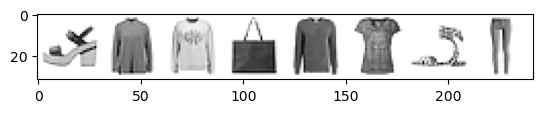

In [8]:
plt.imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

### 5.2 添加噪声

In [14]:
def corrupt(x, amount):
    """ 图像添加噪声函数 """
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1, 1, 1)
    return (1 - amount) * x + amount * noise

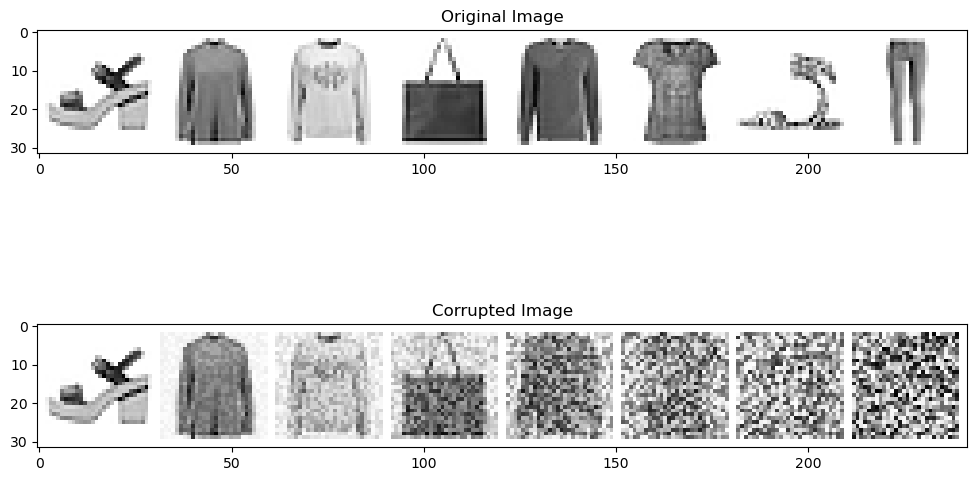

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7))
axs[0].set_title("Original Image")
axs[0].imshow(torchvision.utils.make_grid(x)[0], cmap="Greys")

amount = torch.linspace(0, 1, x.shape[0])
corrupted_x = corrupt(x, amount)
axs[1].set_title("Corrupted Image")
axs[1].imshow(torchvision.utils.make_grid(corrupted_x)[0], cmap="Greys")

### 5.3 BasicUNet 基础UNet

- 下采样
- 上采样


In [20]:
class BasicUNet(nn.Module):
    """ 基础UNet网络 """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        # 下采样 - 通道数增多，特征图缩小
        self.down_layers = nn.ModuleList([nn.Conv2d(in_channels, 32, kernel_size=5, padding=2), 
                                          nn.Conv2d(32, 64, kernel_size=5, padding=2), 
                                          nn.Conv2d(64, 64, kernel_size=5, padding=2)])
        # 上采样 - 通道数减少，特征图增大
        self.up_layers = nn.ModuleList([nn.Conv2d(64, 64, kernel_size=5, padding=2), 
                                        nn.Conv2d(64, 32, kernel_size=5, padding=2), 
                                        nn.Conv2d(32, out_channels, kernel_size=5, padding=2)])
        
        self.activation = nn.ReLU()
        self.downscale = nn.MaxPool2d(kernel_size=2)
        self.upscale = nn.Upsample(scale_factor=2)
        
    def forward(self, x):
        """ 前向传播方法 """
        hidden = []  # 用来存储下采样过程的中间结果 [特征图]
        for idx, layer in enumerate(self.down_layers):
            x = self.activation(layer(x))
            if idx < 2:
                hidden.append(x)
                x = self.downscale(x)
                
        for idx, layer  in enumerate(self.up_layers):
            if idx > 0:
                x = self.upscale(x)
                x = x + hidden.pop()  # ToDo: 测试不加入 hidden 参照的效果
            x = self.activation(layer(x))
        return x

In [22]:
model = BasicUNet(1, 1)
model

BasicUNet(
  (down_layers): ModuleList(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (up_layers): ModuleList(
    (0): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): Conv2d(64, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (2): Conv2d(32, 1, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  )
  (activation): ReLU()
  (downscale): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upscale): Upsample(scale_factor=2.0, mode='nearest')
)

In [24]:
output = model(x)
output.shape, x.shape

(torch.Size([8, 1, 28, 28]), torch.Size([8, 1, 28, 28]))

### 5.4 模型训练

In [27]:
batch_size = 256
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

def train_model(model, dataloader, loss_func, optimizer):
    """ 模型训练函数 """
    total_loss = 0
    for x, _ in dataloader:
        amount = torch.rand(x.shape[0]).to(device)
        corrupted_x = corrupt(x.to(device), amount)
        
        y_hat = model(corrupted_x)
        loss = loss_func(y_hat, x)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [29]:
model = BasicUNet(1, 1)
loss_func = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [43]:
n_epoch = 200

train_loss = []
for i in range(n_epoch):
    loss = train_model(model, dataloader, loss_func, optimizer)
    train_loss.append(loss)
    print(f"Epoch {i+1} loss: {round(loss, 4)}")

Epoch 1 loss: 0.019
Epoch 2 loss: 0.0197
Epoch 3 loss: 0.0195
Epoch 4 loss: 0.0194
Epoch 5 loss: 0.0193
Epoch 6 loss: 0.0196
Epoch 7 loss: 0.0195
Epoch 8 loss: 0.0194
Epoch 9 loss: 0.0192
Epoch 10 loss: 0.0193
Epoch 11 loss: 0.0195
Epoch 12 loss: 0.0197
Epoch 13 loss: 0.019
Epoch 14 loss: 0.019
Epoch 15 loss: 0.0196
Epoch 16 loss: 0.0187
Epoch 17 loss: 0.019
Epoch 18 loss: 0.0192
Epoch 19 loss: 0.0192
Epoch 20 loss: 0.0188
Epoch 21 loss: 0.0192
Epoch 22 loss: 0.0189
Epoch 23 loss: 0.0193
Epoch 24 loss: 0.0193
Epoch 25 loss: 0.0195
Epoch 26 loss: 0.0187
Epoch 27 loss: 0.0193
Epoch 28 loss: 0.0189
Epoch 29 loss: 0.018
Epoch 30 loss: 0.0187
Epoch 31 loss: 0.0188
Epoch 32 loss: 0.0184
Epoch 33 loss: 0.0182
Epoch 34 loss: 0.0188
Epoch 35 loss: 0.0185
Epoch 36 loss: 0.018
Epoch 37 loss: 0.0184
Epoch 38 loss: 0.0182
Epoch 39 loss: 0.0186
Epoch 40 loss: 0.0192
Epoch 41 loss: 0.0179
Epoch 42 loss: 0.0185
Epoch 43 loss: 0.018
Epoch 44 loss: 0.0187
Epoch 45 loss: 0.0185
Epoch 46 loss: 0.018
Epoch

KeyboardInterrupt: 

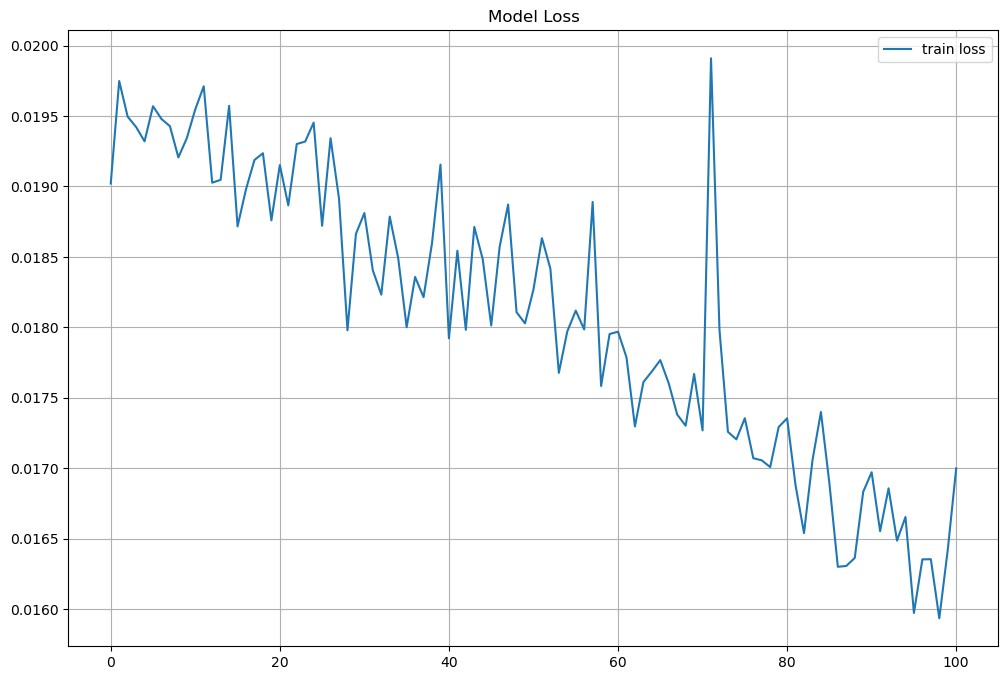

In [46]:
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.figure(figsize=(12, 8))
plt.plot(train_loss, label="train loss")
plt.title("Model Loss")
plt.grid()
plt.legend()
plt.show()

In [ ]:
step_history = [noise.cpu()]
output